In [13]:
import warnings
import torch
import math
import time
import os
import matplotlib.pyplot as plt
from itertools import cycle
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from torch.optim.lr_scheduler import _LRScheduler
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [14]:
from datasets import load_dataset
dataset = load_dataset("EleutherAI/wikitext_document_level", "wikitext-2-raw-v1", split="train")

In [15]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2") # Get the same tokenizer used for GPT-2


print("Vocabulary size:", tokenizer.n_vocab) # Vocabilary size is how many unique tokens the tokenizer can encode
print("End of text token:", tokenizer.eot_token) # End of text token is used to indicate the end of a text sequence
print("Example tokenization:", tokenizer.encode("Hello world!"))

# Convert entire dataset into a single string
# This dataset is small enough to fit into memory
# For larger datasets, you may need to use more 
# sophisticated methods to process the data.
all_text = ""
all_data = dataset["page"]
for example in all_data:
    all_text += "<page> "+ example + " </page>"

# Tokenize the entire text at once
tokenized_text = tokenizer.encode(all_text)


# We will create a function that generates a dataset of examples
# for the language model. The function will take in the number of
# examples to generate, the block size, and the test split.
# It will return the training and test datasets.
def get_dataset(num_examples, context_window_length, test_split=0.1):
    input_blocks = [] # List to store input sequences
    target_blocks = [] # List to store target sequences

    # Use a sliding window to create input/target sequences
    for i in range(0, len(tokenized_text), context_window_length + 1):
        block = tokenized_text[i:i+context_window_length+ 1]
        
        # Skip blocks that are too short
        if len(block) < context_window_length + 1:
            continue

        input_seq = block[:-1]  
        target_seq = block[1:]  

        input_blocks.append(input_seq)
        target_blocks.append(target_seq)
        
        # Stop if we have enough examples
        if len(input_blocks) >= num_examples:
            break

    # Convert to tensors for pytorch and move to gpu
    inputs = torch.tensor(input_blocks, dtype=torch.long).to(device)
    targets = torch.tensor(target_blocks, dtype=torch.long).to(device)

    # Calculate train/test split point
    split_idx = int(num_examples * (1 - test_split))

    # Split into train/test
    train_inputs = inputs[:split_idx]
    train_targets = targets[:split_idx]
    test_inputs = inputs[split_idx:]
    test_targets = targets[split_idx:]
    return train_inputs, train_targets, test_inputs, test_targets

# Get a small dataset
i, o, _, _ = get_dataset(2, 4, 0)
print("Input Shape", i.shape)
print("Output Shape", o.shape)
print("Input Example:")
print(i)
print("Output Example:")
print(o)

Vocabulary size: 50257
End of text token: 50256
Example tokenization: [15496, 995, 0]
Input Shape torch.Size([2, 4])
Output Shape torch.Size([2, 4])
Input Example:
tensor([[   27,  7700,    29,   220],
        [  569, 18354,  7496, 17740]])
Output Example:
tensor([[ 7700,    29,   220,   796],
        [18354,  7496, 17740,  6711]])


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# A simple configuration container
class GPTConfig:
    def __init__(
        self, 
        vocab_size,  # size of the vocabulary, from tokenizer, for gpt2 tokenizer it is 50257
        n_layer,   # number of transformer blocks
        n_head,    # number of attention heads for each transformer block
        n_embd,  # embedding dimension for each token
        seq_len,  # sequence length for the model - e.g. the "context window" 
    
    ):
        self.vocab_size = vocab_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd
        self.seq_len = seq_len
     
test_config = GPTConfig(
    vocab_size=tokenizer.n_vocab,
    n_layer=2,  
    n_head=3,
    n_embd=6,
    seq_len=4,
)

In [17]:
token_embedding = nn.Embedding(test_config.vocab_size, test_config.n_embd).to(device)
test_batch_inputs, _, _, _ = get_dataset(2, test_config.seq_len, 0)
print("Batch shape:", test_batch_inputs.shape, "Batch x Seq Len")
print("After embedding:", token_embedding(test_batch_inputs).shape, "Batch x Seq Len x Embedding Dim")
print("")
print("Before embedding")
print(test_batch_inputs)
print("After embedding")
print(token_embedding(test_batch_inputs))

Batch shape: torch.Size([2, 4]) Batch x Seq Len
After embedding: torch.Size([2, 4, 6]) Batch x Seq Len x Embedding Dim

Before embedding
tensor([[   27,  7700,    29,   220],
        [  569, 18354,  7496, 17740]])
After embedding
tensor([[[ 5.6440e-01,  1.4363e+00,  6.3147e-01, -1.7507e+00,  1.9036e+00,
          -8.6272e-01],
         [ 8.9608e-01, -9.8914e-01, -1.0415e+00, -4.6393e-01, -5.0208e-01,
          -4.1504e-01],
         [ 7.9950e-01, -8.5854e-01, -5.6643e-01,  5.2554e-01, -5.1656e-01,
          -4.9843e-01],
         [-1.7363e+00,  6.6351e-01,  1.2081e-03, -5.5139e-01,  6.2834e-01,
           1.8933e+00]],

        [[ 9.3764e-01, -1.3766e+00,  5.0954e-01,  1.0392e+00,  6.7193e-01,
          -2.6388e-01],
         [-4.2336e-01, -1.2760e+00,  1.9073e+00, -3.4762e-01,  2.3507e-01,
          -1.0432e-01],
         [-3.8835e-01,  7.7038e-01,  7.5895e-01, -4.4180e-01, -9.1909e-01,
          -1.0149e+00],
         [ 2.7417e+00,  1.0233e+00,  7.0663e-01, -8.9115e-01,  9.8352e-01,


In [18]:
def get_position_encoding(seq_len, d, n=10000):
    """
    Computes the positional encoding matrix of shape (seq_len, d).
    
    Args:
        seq_len (int): Length of the sequence.
        d (int): Dimension of the embedding.
        n (float): The base for the exponential term (default 10000 in many Transformer implementations).
    
    Returns:
        torch.Tensor: A tensor of shape (seq_len, d) containing the positional encodings.
    """
    
    P = torch.zeros(seq_len, d).to(device)
    for pos in range(seq_len):
        for i in range(0, d // 2):
            P[pos, 2 * i] = math.sin(pos / (n ** ((2 * i) / d)))
            if i + 1 < d:
                P[pos, 2* i + 1] = math.cos(pos / (n ** ((2 * i) / d)))

    return P.unsqueeze(0)


# Example usage:
position_encoding = get_position_encoding(seq_len=test_config.seq_len, d=test_config.n_embd)
print("Position encoding shape:", position_encoding.shape)

Position encoding shape: torch.Size([1, 4, 6])


In [19]:
test_embeddings = token_embedding(test_batch_inputs)
test_embeddings_with_pos = test_embeddings + position_encoding
print("Token embeddings shape:", test_embeddings.shape)
print("Position encodings shape:", position_encoding.shape)
print("Sum of token embeddings and position encodings:",test_embeddings_with_pos.shape)

Token embeddings shape: torch.Size([2, 4, 6])
Position encodings shape: torch.Size([1, 4, 6])
Sum of token embeddings and position encodings: torch.Size([2, 4, 6])


In [20]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal (masked) self-attention."""

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0, "n_embd must be divisible by n_head"

        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head

        # Single linear layer produces Q, K, V together
        self.qkv = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.proj = nn.Linear(config.n_embd, config.n_embd)

        # Lower-triangular mask prevents attending to future tokens
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.seq_len, config.seq_len)).view(
                1, 1, config.seq_len, config.seq_len
            ),
        )

    def forward(self, x):
        B, T, C = x.size()

        qkv = self.qkv(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        # (B, T, C) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


attn = CausalSelfAttention(test_config).to(device)
attn_out = attn(test_embeddings_with_pos)
print("Attention output shape:", attn_out.shape)

Attention output shape: torch.Size([2, 4, 6])


In [21]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network used inside each transformer block."""

    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Pre-norm transformer block: attention + MLP with residual connections."""

    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


block = TransformerBlock(test_config).to(device)
block_out = block(test_embeddings_with_pos)
print("Transformer block output shape:", block_out.shape)

Transformer block output shape: torch.Size([2, 4, 6])


In [22]:
class GPT(nn.Module):
    """Minimal GPT-style decoder-only language model."""

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_embedding = nn.Embedding(config.vocab_size, config.n_embd)
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: output projection shares weights with token embeddings
        self.lm_head.weight = self.token_embedding.weight

        pos_enc = get_position_encoding(config.seq_len, config.n_embd).squeeze(0)
        self.register_buffer("pos_encoding", pos_enc)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        x = self.token_embedding(idx) + self.pos_encoding[:T].unsqueeze(0)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss


test_model = GPT(test_config).to(device)
test_logits, test_loss = test_model(test_batch_inputs, test_batch_inputs)
print("Logits shape:", test_logits.shape)
print("Loss:", test_loss.item())

Logits shape: torch.Size([2, 4, 50257])
Loss: 10.811068534851074


In [23]:
class TokenBlockDataset(torch.utils.data.Dataset):
    """Sliding-window dataset over pre-tokenized text."""

    def __init__(self, tokens, context_window_length, num_examples=None):
        self.context_window_length = context_window_length
        self.examples = []

        for i in range(0, len(tokens) - context_window_length, context_window_length):
            block = tokens[i : i + context_window_length + 1]
            if len(block) == context_window_length + 1:
                self.examples.append(block)
            if num_examples and len(self.examples) >= num_examples:
                break

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        block = self.examples[idx]
        x = torch.tensor(block[:-1], dtype=torch.long)
        y = torch.tensor(block[1:], dtype=torch.long)
        return x, y


class WarmupCosineScheduler(_LRScheduler):
    """Linear warmup followed by cosine decay."""

    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=0.0, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(self.last_epoch, 1)
        if step < self.warmup_steps:
            scale = step / self.warmup_steps
        else:
            progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            scale = 0.5 * (1.0 + math.cos(math.pi * progress))
        return [max(base_lr * scale, self.min_lr) for base_lr in self.base_lrs]


@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    """Autoregressively sample new tokens from the model."""
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.seq_len :]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        if top_k is not None:
            values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < values[:, [-1]]] = float("-inf")

        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)

    model.train()
    return idx


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=3,
    lr=3e-4,
    warmup_steps=100,
    grad_clip=1.0,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    total_steps = epochs * len(train_loader)
    scheduler = WarmupCosineScheduler(optimizer, warmup_steps, total_steps)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            _, loss = model(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()
            epoch_train_loss += loss.item()

        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                _, loss = model(x, y)
                epoch_val_loss += loss.item()

        avg_train = epoch_train_loss / len(train_loader)
        avg_val = epoch_val_loss / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        print(f"Epoch {epoch + 1}/{epochs} | train loss: {avg_train:.4f} | val loss: {avg_val:.4f}")

    return train_losses, val_losses

In [24]:
# Training hyperparameters — increase these once everything runs on your machine
train_config = GPTConfig(
    vocab_size=tokenizer.n_vocab,
    n_layer=4,
    n_head=4,
    n_embd=128,
    seq_len=128,
)

num_train_examples = 2000
num_val_examples = 200
batch_size = 16

full_dataset = TokenBlockDataset(tokenized_text, train_config.seq_len, num_examples=num_train_examples + num_val_examples)
split_idx = int(len(full_dataset) * (num_train_examples / (num_train_examples + num_val_examples)))

train_dataset = torch.utils.data.Subset(full_dataset, range(0, split_idx))
val_dataset = torch.utils.data.Subset(full_dataset, range(split_idx, len(full_dataset)))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

model = GPT(train_config).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=3e-4,
    warmup_steps=50,
)

Model parameters: 7,226,240
Epoch 1/5 | train loss: 9.2620 | val loss: 7.8673
Epoch 2/5 | train loss: 7.2879 | val loss: 7.6986
Epoch 3/5 | train loss: 7.2218 | val loss: 7.7188
Epoch 4/5 | train loss: 7.2048 | val loss: 7.7282
Epoch 5/5 | train loss: 7.1951 | val loss: 7.7295


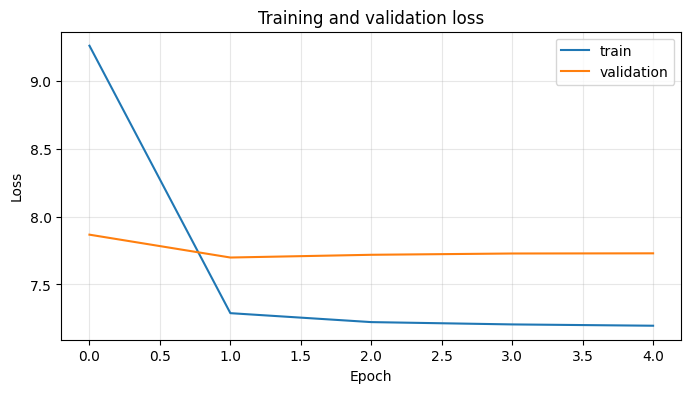

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# Quick sanity check — generate right after training (full inference section below)
prompt = "The history of artificial intelligence"
context = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)

with torch.no_grad():
    generated = generate(model, context, max_new_tokens=80, temperature=0.8, top_k=40)

completion = tokenizer.decode(generated[0, context.size(1):].tolist())
print("Prompt:")
print(prompt)
print("\nCompletion:")
print(completion)
print("\nFull output:")
print(tokenizer.decode(generated[0].tolist()))

Prompt:
The history of artificial intelligence

Completion:
 . and in
 . from . in of . . . and , @
 the of the in " The in on a was ,  a in , , . with .  , , . , a- and ' .
 the the- in ' " . to ' ,@ , the@ , of , to at of as 
 , ,  ' to on the to the , @

Full output:
The history of artificial intelligence . and in
 . from . in of . . . and , @
 the of the in " The in on a was ,  a in , , . with .  , , . , a- and ' .
 the the- in ' " . to ' ,@ , the@ , of , to at of as 
 , ,  ' to on the to the , @


In [27]:
# Save trained weights so you can run inference without re-training
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, "gpt_scratch.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": vars(train_config),
    },
    checkpoint_path,
)
print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to checkpoints/gpt_scratch.pt


## Inference

Load a saved checkpoint and generate text. You can run the cells below on their own after training — even in a fresh kernel session, as long as the earlier model class definitions (cells 4–10) have been executed.

In [28]:
checkpoint_path = os.path.join("checkpoints", "gpt_scratch.pt")


def load_gpt_checkpoint(path, device=device):
    """Rebuild the model architecture and load saved weights."""
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    config = GPTConfig(**checkpoint["config"])

    inference_model = GPT(config).to(device)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()

    return inference_model, config


@torch.no_grad()
def complete_text(
    model,
    prompt,
    max_new_tokens=120,
    temperature=0.8,
    top_k=40,
    tokenizer=tokenizer,
    device=device,
):
    """
    Run autoregressive inference from a text prompt.

    Returns:
        full_text: prompt + generated continuation
        completion: only the newly generated tokens (decoded)
    """
    prompt_tokens = tokenizer.encode(prompt)
    context = torch.tensor([prompt_tokens], dtype=torch.long, device=device)

    generated = generate(
        model,
        context,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
    )

    completion = tokenizer.decode(generated[0, len(prompt_tokens):].tolist())
    full_text = tokenizer.decode(generated[0].tolist())
    return full_text, completion


def run_inference(model, prompts, **kwargs):
    """Generate completions for one or more prompts and print results."""
    for i, prompt in enumerate(prompts, start=1):
        full_text, completion = complete_text(model, prompt, **kwargs)
        print(f"--- Example {i} ---")
        print(f"Prompt: {prompt}")
        print(f"Completion: {completion.strip() or '[empty]'}")
        print(f"Full output: {full_text}\n")


# Load the checkpoint saved above (falls back to in-memory model if file missing)
if os.path.exists(checkpoint_path):
    inference_model, _ = load_gpt_checkpoint(checkpoint_path, device)
    print(f"Loaded model from {checkpoint_path}")
else:
    inference_model = model
    print("No checkpoint found — using the in-memory trained model")

Loaded model from checkpoints/gpt_scratch.pt


In [29]:
# Generate text from several prompts
inference_prompts = [
    "The history of artificial intelligence",
    "In the year 2050, humans will",
    "The capital of France is",
    "Machine learning is a field that",
]

run_inference(
    inference_model,
    inference_prompts,
    max_new_tokens=100,
    temperature=0.8,
    top_k=40,
)

--- Example 1 ---
Prompt: The history of artificial intelligence
Completion: = =  ) . .@ and the . were by@ . - . , , of in on the the was the. ( the " the- the , in in of the . the@ , a@ of , were- @ , ) ; to in ; , ' . the the in the the and , on , ,
 . . , the the that in , of  and for the . . that as 
 " ,  = the  of the . on in .
Full output: The history of artificial intelligence = =  ) . .@ and the . were by@ . - . , , of in on the the was the. ( the " the- the , in in of the . the@ , a@ of , were- @ , ) ; to in ; , ' . the the in the the and , on , ,
 . . , the the that in , of  and for the . . that as 
 " ,  = the  of the . on in .

--- Example 2 ---
Prompt: In the year 2050, humans will
Completion: The ands of = a of = with " @ which a and . is ) , the , .  in that , the , for- , " the the the . and in of on , " . with = ' The@
 . a the with , " the the =  and withs as The a = he a was thes ,
 the The a the = of , thes the. on. = the in  . was and  the ) in of by to "
Full ou

In [30]:
# Interactive-style inference — change the prompt and re-run this cell
custom_prompt = "Once upon a time in a distant galaxy"

full_text, completion = complete_text(
    inference_model,
    custom_prompt,
    max_new_tokens=150,
    temperature=0.7,
    top_k=50,
)

print("Prompt:")
print(custom_prompt)
print("\nGenerated continuation:")
print(completion)

Prompt:
Once upon a time in a distant galaxy

Generated continuation:
 the ins and a a
 ' the The = the in as , the , . the the that the   and . " for The ' " of@ that as were . the to In ,s ,. and of the and at first . , and is with with was " the in .
 to . , . . , with was@ . , = @ the "@ a ,  his , was to , the
 the the . and was on , = with @ the the , in the was
 the s , , the . = . the the with not , the the of and at ,@ in in and , = and the ( , , the. the the@ , to and of  . , ( ,
